<a href="https://colab.research.google.com/github/yooongZa/AIFFEL_Quest_EPA/blob/main/0904_News_Bot_Projct.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 뉴스 요약봇 만들기 [프로젝트]

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## 1. 뉴스기사 요약해보기

> 💡 **GPU 런타임 사용을 권장합니다.**

새로운 데이터셋에 대해서 추상적 요약과 추출적 요약을 모두 해보는 시간을 가져봐요.

먼저 주요 라이브러리 버전을 확인해 보죠.

### 답안 구현 기준

- `Based-On: NLP-01-02-C012@40a30afc8988` — 공백 tokenization(토큰화), word↔ID, padding(패딩)
- 참고 예제: `NLP-01-01-C008@2fe05534e124`, `NLP-01-02-C011@a69ad5a21a6c`, `MLDL-03-02-C057@46154b169e1c`, `MLDL-03-02-C061@1eeb3dd65f47`
- 직접 레슨: `뉴스 요약봇 만들기.ipynb` (`lms_export_with_user_state`)

레슨의 **전처리 → 분할 → 단어장 → 패딩 → Encoder/Decoder/Attention → 학습 → 추론 → Summa** 순서를 그대로 따릅니다.

In [18]:
from google.colab import drive
from pathlib import Path
import os

# 기본 마운트 위치에 다른 파일이 있으면 별도 폴더를 사용합니다.
drive_root = Path("/content/drive")
if not os.path.ismount(drive_root):
    if drive_root.exists() and any(drive_root.iterdir()):
        drive_root = Path("/content/google_drive")
    drive.mount(str(drive_root))

data_dir = drive_root / "MyDrive/Aiffel_EPA/news_summarization/data"
data_dir.mkdir(parents=True, exist_ok=True)
print("Google Drive 경로:", data_dir)

Google Drive 경로: /content/drive/MyDrive/Aiffel_EPA/news_summarization/data


In [19]:
!pip install -q summa nltk

In [20]:
import html
import random
import re
from collections import Counter
from copy import deepcopy

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from nltk.corpus import stopwords
from torch.utils.data import DataLoader, TensorDataset

nltk.download("stopwords", quiet=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## Step 1. 데이터 수집하기

데이터는 아래 링크에 있는 뉴스 기사 데이터(`news_summary_more.csv`)를 사용하세요.
- [sunnysai12345/News_Summary](https://github.com/sunnysai12345/News_Summary)<br>

아래의 코드로 데이터를 다운로드할 수 있어요.

In [21]:
from urllib.request import urlretrieve

data_url = (
    "https://raw.githubusercontent.com/sunnysai12345/News_Summary/"
    "a86081060bbb17c5686b478b2f7f18df6e87303d/news_summary_more.csv"
)
data_path = data_dir / "news_summary_more.csv"

# Drive에 파일이 없을 때만 다운로드합니다.
if not data_path.exists():
    urlretrieve(data_url, data_path)

data = pd.read_csv(data_path, encoding="iso-8859-1")
print("전체 샘플 수:", len(data))

전체 샘플 수: 98401


In [22]:
data.sample(10, random_state=SEED)

,headlines,text
32571,K'taka students to get extra marks if parents ...,Students in Karnataka will get extra marks if ...
35184,Syria shoots down missiles fired at two air bases,Syrian anti-aircraft defences on Monday shot d...
59997,Dinosaur-like animal's fossil found in Uttarak...,A Dinosaur-like creature's fossil was found du...
64665,"UP may merge Shia, Sunni Waqf boards to preven...",The Uttar Pradesh government is planning to fo...
15343,Egypt actress gets 2 yrs jail for 'fake news' ...,Egyptian activist-actress Amal Fathy has been ...
52898,Jeff Bezos added more wealth in 2017 than GDP ...,World's richest person and Amazon CEO Jeff Bez...
95149,Bangladeshi captain Mortaza announces retireme...,Bangladesh cricket team's limited overs captai...
76915,Mexican drug lord El Chapo questions US extrad...,Mexican drug lord Joaquin 'El Chapo' Guzman ha...
49398,N Korea supplies ballistic missiles to Myanmar...,Independent United Nations (UN) monitors have ...
74036,Thenga mila hamme: Harbhajan responds to home ...,After reports of three Amrapali Group companie...


이 데이터는 기사의 본문에 해당되는 text와 headlines 두 가지 열로 구성되어 있습니다.<br>
추상적 요약을 하는 경우에는 text를 본문, headlines를 이미 요약된 데이터로 삼아서 모델을 학습할 수 있어요. 추출적 요약을 하는 경우에는 오직 text열만을 사용하세요.

## Step 2. 데이터 전처리하기 (추상적 요약)

실습에서 사용된 전처리를 참고하여 각자 필요하다고 생각하는 전처리를 추가 사용하여 텍스트를 정규화 또는 정제해 보세요. 만약, 불용어 제거를 선택한다면 상대적으로 길이가 짧은 요약 데이터에 대해서도 불용어를 제거하는 것이 좋을지 고민해 보세요.

### 답안 2. 전처리와 정수 인코딩

`Text`에서는 stopword(불용어)를 제거하고, 짧은 정답인 `Summary`에서는 제거하지 않습니다.

In [23]:
# 프로젝트 데이터의 열 이름을 레슨과 같게 바꿉니다.
data = data[["text", "headlines"]].rename(
    columns={"text": "Text", "headlines": "Summary"}
)
data = data.drop_duplicates(subset=["Text"]).dropna().copy()

# Summa 비교에는 전처리 전 원문을 사용합니다.
data["OriginalText"] = data["Text"]
print("중복과 결측치 제거 후:", len(data))

중복과 결측치 제거 후: 98360


In [24]:
# 레슨에서 사용한 영어 축약형 정규화 예시입니다.
contractions = {
    "ain't": "is not", "aren't": "are not", "can't": "cannot",
    "couldn't": "could not", "didn't": "did not", "doesn't": "does not",
    "don't": "do not", "hadn't": "had not", "hasn't": "has not",
    "haven't": "have not", "he's": "he is", "i'm": "i am",
    "isn't": "is not", "it's": "it is", "let's": "let us",
    "shouldn't": "should not", "that's": "that is", "there's": "there is",
    "they're": "they are", "wasn't": "was not", "we're": "we are",
    "weren't": "were not", "what's": "what is", "where's": "where is",
    "who's": "who is", "won't": "will not", "wouldn't": "would not",
    "you're": "you are", "you've": "you have"
}
stop_words = set(stopwords.words("english"))

def preprocess_sentence(sentence, remove_stopwords=True):
    sentence = sentence.lower()
    sentence = re.sub("<[^>]*>", " ", sentence)       # HTML 태그 제거
    sentence = html.unescape(sentence)                  # &amp; 같은 문자 변환
    sentence = re.sub(r"\([^)]*\)", " ", sentence)    # 괄호 내용 제거
    sentence = " ".join(
        contractions.get(word, word) for word in sentence.split()
    )
    sentence = re.sub(r"'s", "", sentence)
    sentence = re.sub("[^a-zA-Z]", " ", sentence)

    words = sentence.split()
    if remove_stopwords:
        words = [word for word in words if word not in stop_words]
    return " ".join(word for word in words if len(word) > 1)

In [25]:
data["Text"] = data["Text"].apply(preprocess_sentence)
data["Summary"] = data["Summary"].apply(
    lambda sentence: preprocess_sentence(sentence, remove_stopwords=False)
)

# 전처리 후 빈 문자열은 제거합니다.
data = data.replace("", np.nan).dropna().reset_index(drop=True)
data[["Text", "Summary"]].head()

,Text,Summary
0,saurav kant alumnus upgrad iiit pg program mac...,upgrad learner switches to career in ml al wit...
1,kunal shah credit card bill payment platform c...,delhi techie wins free food from swiggy for on...
2,new zealand defeated india wickets fourth odi ...,new zealand end rohit sharma led india match w...
3,aegon life iterm insurance plan customers enjo...,aegon life iterm insurance plan helps customer...
4,speaking sexual harassment allegations rajkuma...,have known hirani for yrs what if metoo claims...


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

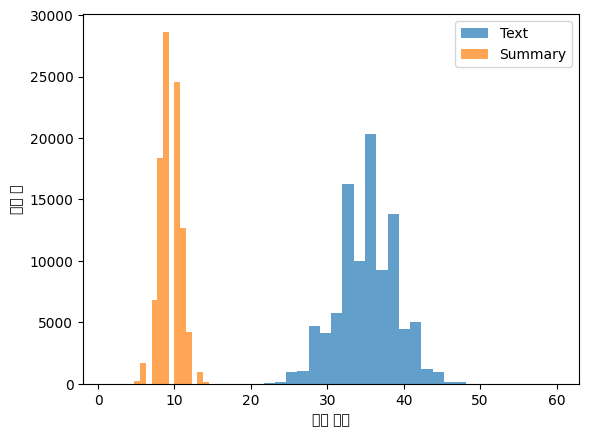

훈련 데이터: 21691
테스트 데이터: 5423


In [26]:
text_lengths = data["Text"].str.split().str.len()
summary_lengths = data["Summary"].str.split().str.len()

plt.hist(text_lengths, bins=40, alpha=0.7, label="Text")
plt.hist(summary_lengths, bins=20, alpha=0.7, label="Summary")
plt.xlabel("문장 길이")
plt.ylabel("샘플 수")
plt.legend()
plt.show()

text_max_len = 50
summary_max_len = 8
data = data[
    (text_lengths <= text_max_len) &
    (summary_lengths <= summary_max_len)
].copy()

# 디코더 입력에는 시작 토큰, 정답에는 종료 토큰을 붙입니다.
data["decoder_input"] = "sostoken " + data["Summary"]
data["decoder_target"] = data["Summary"] + " eostoken"

# 데이터를 섞은 뒤 8:2로 나눕니다.
data = data.sample(frac=1, random_state=SEED).reset_index(drop=True)
split_index = int(len(data) * 0.8)
train_data = data.iloc[:split_index].reset_index(drop=True)
test_data = data.iloc[split_index:].reset_index(drop=True)

print("훈련 데이터:", len(train_data))
print("테스트 데이터:", len(test_data))

In [27]:
def build_vocab(texts, max_size):
    counter = Counter()
    for text in texts:
        counter.update(text.split())

    vocab = {"<PAD>": 0, "<UNK>": 1}
    for word, _ in counter.most_common(max_size - 2):
        vocab[word] = len(vocab)
    return vocab

def text_to_sequences(texts, vocab):
    sequences = []
    for text in texts:
        sequence = [vocab.get(word, vocab["<UNK>"]) for word in text.split()]
        sequences.append(sequence)
    return sequences

def pad_sequences(sequences, max_len):
    result = torch.zeros((len(sequences), max_len), dtype=torch.long)
    for row, sequence in enumerate(sequences):
        length = min(len(sequence), max_len)
        result[row, :length] = torch.tensor(sequence[:length])
    return result

src_vocab = build_vocab(train_data["Text"], max_size=8000)
target_texts = list(train_data["decoder_input"]) + list(train_data["decoder_target"])
tar_vocab = build_vocab(target_texts, max_size=2000)

# SOS/EOS가 단어장 크기 제한으로 빠지는 경우를 막습니다.
for token in ["sostoken", "eostoken"]:
    if token not in tar_vocab:
        tar_vocab[token] = len(tar_vocab)

decoder_max_len = summary_max_len + 1

encoder_input_train = pad_sequences(
    text_to_sequences(train_data["Text"], src_vocab), text_max_len
)
encoder_input_test = pad_sequences(
    text_to_sequences(test_data["Text"], src_vocab), text_max_len
)
decoder_input_train = pad_sequences(
    text_to_sequences(train_data["decoder_input"], tar_vocab), decoder_max_len
)
decoder_target_train = pad_sequences(
    text_to_sequences(train_data["decoder_target"], tar_vocab), decoder_max_len
)
decoder_input_test = pad_sequences(
    text_to_sequences(test_data["decoder_input"], tar_vocab), decoder_max_len
)
decoder_target_test = pad_sequences(
    text_to_sequences(test_data["decoder_target"], tar_vocab), decoder_max_len
)

print("인코더 입력 shape:", encoder_input_train.shape)
print("디코더 입력 shape:", decoder_input_train.shape)

인코더 입력 shape: torch.Size([21691, 50])
디코더 입력 shape: torch.Size([21691, 9])


## Step 3. 어텐션 메커니즘 사용하기 (추상적 요약)

일반적인 seq2seq보다는 어텐션 메커니즘을 사용한 seq2seq를 사용하는 것이 더 나은 성능을 얻을 수 있어요. 실습 내용을 참고하여 어텐션 메커니즘을 사용한 seq2seq를 설계해 보세요.

### 답안 3. Encoder–Decoder와 Attention

Encoder는 원문을 읽고, Decoder는 정답 요약을 한 단어씩 예측합니다. Attention은 예측할 때 원문의 어느 부분을 볼지 계산합니다.

In [28]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, num_layers=3,
            dropout=0.4, batch_first=True
        )

    def forward(self, x):
        x = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(x)
        return outputs, hidden, cell


class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, num_layers=3,
            dropout=0.4, batch_first=True
        )

    def forward(self, x, hidden, cell):
        x = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(x, (hidden, cell))
        return outputs, hidden, cell


class Attention(nn.Module):
    def forward(self, decoder_outputs, encoder_outputs, encoder_input):
        scores = torch.bmm(decoder_outputs, encoder_outputs.transpose(1, 2))
        pad_mask = encoder_input.eq(0).unsqueeze(1)
        scores = scores.masked_fill(pad_mask, -1e9)
        weights = F.softmax(scores, dim=-1)
        return torch.bmm(weights, encoder_outputs)


class Seq2SeqWithAttention(nn.Module):
    def __init__(self, src_vocab_size, tar_vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, embedding_dim, hidden_size)
        self.decoder = Decoder(tar_vocab_size, embedding_dim, hidden_size)
        self.attention = Attention()
        self.concat = nn.Linear(hidden_size * 2, hidden_size)
        self.output = nn.Linear(hidden_size, tar_vocab_size)

    def forward(self, encoder_input, decoder_input):
        encoder_outputs, hidden, cell = self.encoder(encoder_input)
        decoder_outputs, _, _ = self.decoder(decoder_input, hidden, cell)
        context = self.attention(decoder_outputs, encoder_outputs, encoder_input)
        combined = torch.cat([decoder_outputs, context], dim=-1)
        combined = torch.tanh(self.concat(combined))
        return self.output(combined)

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

embedding_dim = 128
hidden_size = 256
batch_size = 256
epochs = 50
patience = 2

model = Seq2SeqWithAttention(
    len(src_vocab), len(tar_vocab), embedding_dim, hidden_size
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

train_dataset = TensorDataset(
    encoder_input_train, decoder_input_train, decoder_target_train
)
test_dataset = TensorDataset(
    encoder_input_test, decoder_input_test, decoder_target_test
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print("사용 장치:", device)

사용 장치: cuda


In [13]:
train_losses = []
val_losses = []
best_val_loss = float("inf")
best_model = None
wait = 0

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for encoder_input, decoder_input, target in train_loader:
        encoder_input = encoder_input.to(device)
        decoder_input = decoder_input.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        output = model(encoder_input, decoder_input)
        loss = criterion(output.reshape(-1, output.size(-1)), target.reshape(-1))
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for encoder_input, decoder_input, target in test_loader:
            encoder_input = encoder_input.to(device)
            decoder_input = decoder_input.to(device)
            target = target.to(device)

            output = model(encoder_input, decoder_input)
            loss = criterion(output.reshape(-1, output.size(-1)), target.reshape(-1))
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss /= len(test_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1

    if wait >= patience:
        print("Early Stopping")
        break

# 가장 성능이 좋았던 모델을 복원하고 Drive에 저장합니다.
model.load_state_dict(best_model)
model_path = data_dir / "news_seq2seq_attention.pt"
torch.save(model.state_dict(), model_path)
print("모델 저장 완료:", model_path)

# 저장된 모델을 불러오는 방법
model.load_state_dict(torch.load(model_path, map_location=device))

Epoch 1/50 | Train Loss: 5.0489 | Val Loss: 4.7004
Epoch 2/50 | Train Loss: 4.7045 | Val Loss: 4.6323
Epoch 3/50 | Train Loss: 4.6488 | Val Loss: 4.5799
Epoch 4/50 | Train Loss: 4.5754 | Val Loss: 4.5043
Epoch 5/50 | Train Loss: 4.4859 | Val Loss: 4.4347
Epoch 6/50 | Train Loss: 4.3821 | Val Loss: 4.3279
Epoch 7/50 | Train Loss: 4.2727 | Val Loss: 4.2477
Epoch 8/50 | Train Loss: 4.1598 | Val Loss: 4.1438
Epoch 9/50 | Train Loss: 4.0458 | Val Loss: 4.0572
Epoch 10/50 | Train Loss: 3.9405 | Val Loss: 3.9908
Epoch 11/50 | Train Loss: 3.8394 | Val Loss: 3.9319
Epoch 12/50 | Train Loss: 3.7420 | Val Loss: 3.8687
Epoch 13/50 | Train Loss: 3.6422 | Val Loss: 3.8256
Epoch 14/50 | Train Loss: 3.5482 | Val Loss: 3.7964
Epoch 15/50 | Train Loss: 3.4554 | Val Loss: 3.7591
Epoch 16/50 | Train Loss: 3.3610 | Val Loss: 3.7308
Epoch 17/50 | Train Loss: 3.2757 | Val Loss: 3.7083
Epoch 18/50 | Train Loss: 3.1839 | Val Loss: 3.6940
Epoch 19/50 | Train Loss: 3.0991 | Val Loss: 3.6986
Epoch 20/50 | Train L

<All keys matched successfully>

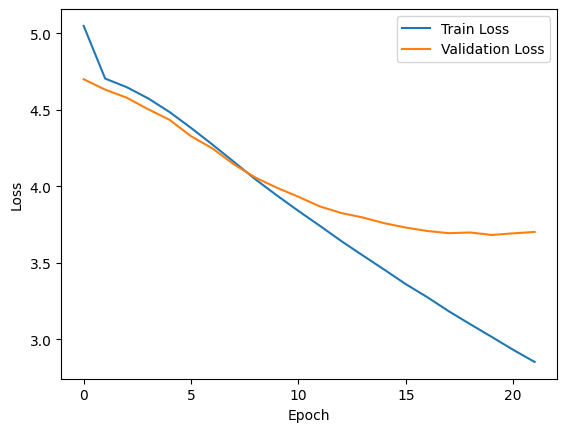

In [14]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Step 4. 실제 결과와 요약문 비교하기 (추상적 요약)

원래의 요약문(headlines 열)과 학습을 통해 얻은 추상적 요약의 결과를 비교해 보세요.

### 답안 4. 요약문 생성하기

첫 입력은 `sostoken`이며, 이후에는 모델이 예측한 단어를 다음 입력으로 사용합니다. `eostoken`을 예측하면 생성을 끝냅니다.

In [15]:
src_index_to_word = {index: word for word, index in src_vocab.items()}
tar_index_to_word = {index: word for word, index in tar_vocab.items()}

def sequence_to_text(sequence, index_to_word):
    words = []
    for index in sequence:
        index = int(index)
        if index != 0:
            words.append(index_to_word.get(index, "<UNK>"))
    return " ".join(words)

def decode_sequence(input_sequence):
    model.eval()
    input_sequence = input_sequence.unsqueeze(0).to(device)
    summary = []

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(input_sequence)
        next_word = tar_vocab["sostoken"]

        for _ in range(summary_max_len):
            decoder_input = torch.tensor([[next_word]], device=device)
            decoder_output, hidden, cell = model.decoder(
                decoder_input, hidden, cell
            )
            context = model.attention(
                decoder_output, encoder_outputs, input_sequence
            )
            combined = torch.cat([decoder_output, context], dim=-1)
            combined = torch.tanh(model.concat(combined))
            prediction = model.output(combined)
            next_word = prediction.argmax(dim=-1).item()

            word = tar_index_to_word.get(next_word, "<UNK>")
            if word == "eostoken":
                break
            if word not in ["<PAD>", "sostoken"]:
                summary.append(word)

    return " ".join(summary)

In [16]:
for index in range(min(10, len(test_data))):
    actual_summary = sequence_to_text(
        decoder_target_test[index], tar_index_to_word
    ).replace("eostoken", "").strip()
    predicted_summary = decode_sequence(encoder_input_test[index])

    print("원문:", test_data.loc[index, "OriginalText"][:300])
    print("실제 요약:", actual_summary)
    print("예측 요약:", predicted_summary)
    print("-" * 80)

원문: Indian swimmer Virdhawal Khade finished fourth in the Asian Games' men's 50m freestyle final, missing the third spot and the bronze medal by a margin of 0.01 seconds. Khade, who won a bronze in the 50m Butterfly category at the Asian Games 2010, finished behind two Japanese swimmers who took the sec
실제 요약: indian <UNK> <UNK> asian games <UNK> by seconds
예측 요약: <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK>
--------------------------------------------------------------------------------
원문: Icelandic rock band Sigur RÃÂ³s is set to launch a limited edition line of cannabis-infused medicated candies named 'Wild Sigurberry' next week. The candies have been inspired by the flavours of blackberries, strawberries and blueberries. A box of nine candies can be bought for $40 (Ã¢ÂÂ¹2,579). T
실제 요약: <UNK> music group to launch <UNK> <UNK>
예측 요약: <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK>
--------------------------------------------------------------------------------
원문: Police seize

## Step 5. Summa를 이용해서 추출적 요약해보기

### 답안 5. 추상적 요약과 추출적 요약 비교

추상적 요약은 모델이 새 문장을 만들고, Summa의 추출적 요약은 원문에서 중요한 문장을 선택합니다.

In [17]:
from summa.summarizer import summarize

for index in range(min(5, len(test_data))):
    original_text = test_data.loc[index, "OriginalText"]
    abstractive_summary = decode_sequence(encoder_input_test[index])
    extractive_summary = summarize(original_text, ratio=0.4)
    if not extractive_summary:
        extractive_summary = summarize(original_text, words=30)

    print("원문:", original_text[:300])
    print("실제 요약:", test_data.loc[index, "Summary"])
    print("추상적 요약:", abstractive_summary)
    print("추출적 요약:", extractive_summary)
    print("-" * 80)

원문: Indian swimmer Virdhawal Khade finished fourth in the Asian Games' men's 50m freestyle final, missing the third spot and the bronze medal by a margin of 0.01 seconds. Khade, who won a bronze in the 50m Butterfly category at the Asian Games 2010, finished behind two Japanese swimmers who took the sec
실제 요약: indian swimmer misses asian games bronze by seconds
추상적 요약: <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK>
추출적 요약: Indian swimmer Virdhawal Khade finished fourth in the Asian Games' men's 50m freestyle final, missing the third spot and the bronze medal by a margin of 0.01 seconds.
--------------------------------------------------------------------------------
원문: Icelandic rock band Sigur RÃÂ³s is set to launch a limited edition line of cannabis-infused medicated candies named 'Wild Sigurberry' next week. The candies have been inspired by the flavours of blackberries, strawberries and blueberries. A box of nine candies can be bought for $40 (Ã¢ÂÂ¹2,579). T
실제 요약: icelandic mu

### 결과 확인

- Loss 그래프가 전체적으로 내려가는지 확인합니다.
- 추상적 요약이 원문의 핵심 단어를 포함하는지 확인합니다.
- Summa 결과는 원문 문장의 일부인지 확인합니다.
- 문법과 의미의 자연스러움은 출력 결과를 직접 읽고 비교합니다.

## 프로젝트 제출

## 루브릭

- Abstractive 모델 구성을 위한 텍스트 전처리 단계가 체계적으로 진행되었다.
    - 분석단계, 정제단계, 정규화와 불용어 제거, 데이터셋 분리, 인코딩 과정이 빠짐없이 체계적으로 진행되었다.
- 텍스트 요약모델이 성공적으로 학습되었음을 확인하였다.
    - 모델 학습이 진행되면서 train loss와 validation loss가 감소하는 경향을 그래프를 통해 확인했으며, 실제 요약문에 있는 핵심 단어들이 요약 문장 안에 포함되었다.
- Extractive 요약을 시도해 보고 Abstractive 요약 결과과 함께 비교해 보았다.
    - 두 요약 결과를 문법완성도 측면과 핵심단어 포함 측면으로 나누어 비교하고 분석 결과를 표로 정리하여 제시하였다.

> **[과제] 과제 제출**
>
> 노트북 파일(.ipynb)로 과제를 수행 후 출력이 저장된 상태의 깃헙 파일 링크를 입력해 주세요.
>
> 제출은 LMS 레슨 화면의 과제 카드에서 GitHub 링크로 합니다(이 파일에 적으면 제출되지 않습니다).